<a href="https://colab.research.google.com/github/horizonking/-myproject/blob/main/Copy_of_Untitled24.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Analysis Report
1. Define the Problem

Objective: Determine which financial indicators are associated with corporate bankruptcy and identify variables that best predict whether a company goes bankrupt.

#Import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns

In [ ]:
pd.set_option('display.max_columns', None)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 1. LOAD DATASET

In [2]:
import pandas as pd

df = pd.read_csv("/content/data.csv")

print("="*60)
print("FIRST FIVE ROWS")
print("="*60)
print(df.head())

print("\n")

FIRST FIVE ROWS
   Bankrupt?   ROA(C) before interest and depreciation before interest  \
0          1                                           0.370594          
1          1                                           0.464291          
2          1                                           0.426071          
3          1                                           0.399844          
4          1                                           0.465022          

    ROA(A) before interest and % after tax  \
0                                 0.424389   
1                                 0.538214   
2                                 0.499019   
3                                 0.451265   
4                                 0.538432   

    ROA(B) before interest and depreciation after tax  \
0                                           0.405750    
1                                           0.516730    
2                                           0.472295    
3                                 

# 2. DATASET INFORMATION

In [3]:
print("="*60)
print("DATASET INFORMATION")
print("="*60)

print(df.info())

print("\nShape of dataset:", df.shape)

print("\nNumber of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Bankrupt?                                                 6819 non-null   int64  
 1    ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2    ROA(A) before interest and % after tax                   6819 non-null   float64
 3    ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4    Operating Gross Margin                                   6819 non-null   float64
 5    Realized Sales Gross Margin                              6819 non-null   float64
 6    Operating Profit Rate                                    6819 non-null   float64
 7    Pre-tax net Interest Rate                                6819 non-null   float64
 8 

# 3. CHECK DATA TYPES

In [4]:
print("="*60)
print("DATA TYPES")
print("="*60)

print(df.dtypes)

DATA TYPES
Bankrupt?                                                     int64
 ROA(C) before interest and depreciation before interest    float64
 ROA(A) before interest and % after tax                     float64
 ROA(B) before interest and depreciation after tax          float64
 Operating Gross Margin                                     float64
                                                             ...   
 Liability to Equity                                        float64
 Degree of Financial Leverage (DFL)                         float64
 Interest Coverage Ratio (Interest expense to EBIT)         float64
 Net Income Flag                                              int64
 Equity to Liability                                        float64
Length: 96, dtype: object


# 4. CHECK MISSING VALUES

In [6]:
print("="*60)
print("MISSING VALUES")
print("="*60)

missing = df.isnull().sum()

print(missing[missing > 0])

print("\nTotal Missing Values:", df.isnull().sum().sum())


MISSING VALUES
Series([], dtype: int64)

Total Missing Values: 0


# 5. CHECK DUPLICATES

In [7]:
print("="*60)
print("DUPLICATES")
print("="*60)

duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

DUPLICATES
Duplicate Rows: 0


# 6. DESCRIPTIVE STATISTICS

In [8]:
print("="*60)
print("DESCRIPTIVE STATISTICS")
print("="*60)

print(df.describe().T)

DESCRIPTIVE STATISTICS
                                                     count      mean  \
Bankrupt?                                           6819.0  0.032263   
 ROA(C) before interest and depreciation before...  6819.0  0.505180   
 ROA(A) before interest and % after tax             6819.0  0.558625   
 ROA(B) before interest and depreciation after tax  6819.0  0.553589   
 Operating Gross Margin                             6819.0  0.607948   
...                                                    ...       ...   
 Liability to Equity                                6819.0  0.280365   
 Degree of Financial Leverage (DFL)                 6819.0  0.027541   
 Interest Coverage Ratio (Interest expense to E...  6819.0  0.565358   
 Net Income Flag                                    6819.0  1.000000   
 Equity to Liability                                6819.0  0.047578   

                                                         std  min       25%  \
Bankrupt?                        

# 7. TARGET VARIABLE DISTRIBUTION

BANKRUPTCY DISTRIBUTION
Bankrupt?
0    6599
1     220
Name: count, dtype: int64

Percentage
Bankrupt?
0    96.77372
1     3.22628
Name: proportion, dtype: float64


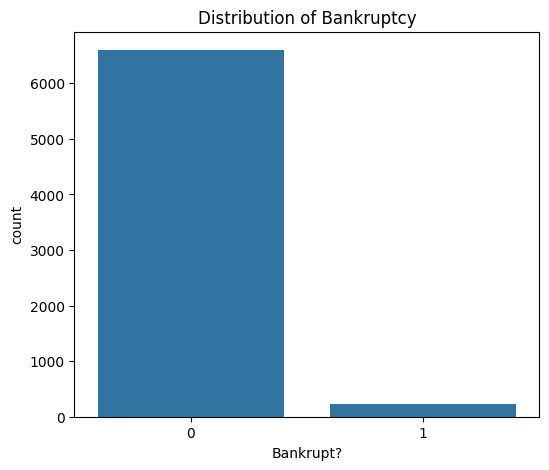

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

print("="*60)
print("BANKRUPTCY DISTRIBUTION")
print("="*60)

print(df["Bankrupt?"].value_counts())

print("\nPercentage")

print(df["Bankrupt?"].value_counts(normalize=True)*100)

plt.figure(figsize=(6,5))

sns.countplot(x="Bankrupt?", data=df)

plt.title("Distribution of Bankruptcy")

plt.show()

# 8. HISTOGRAMS

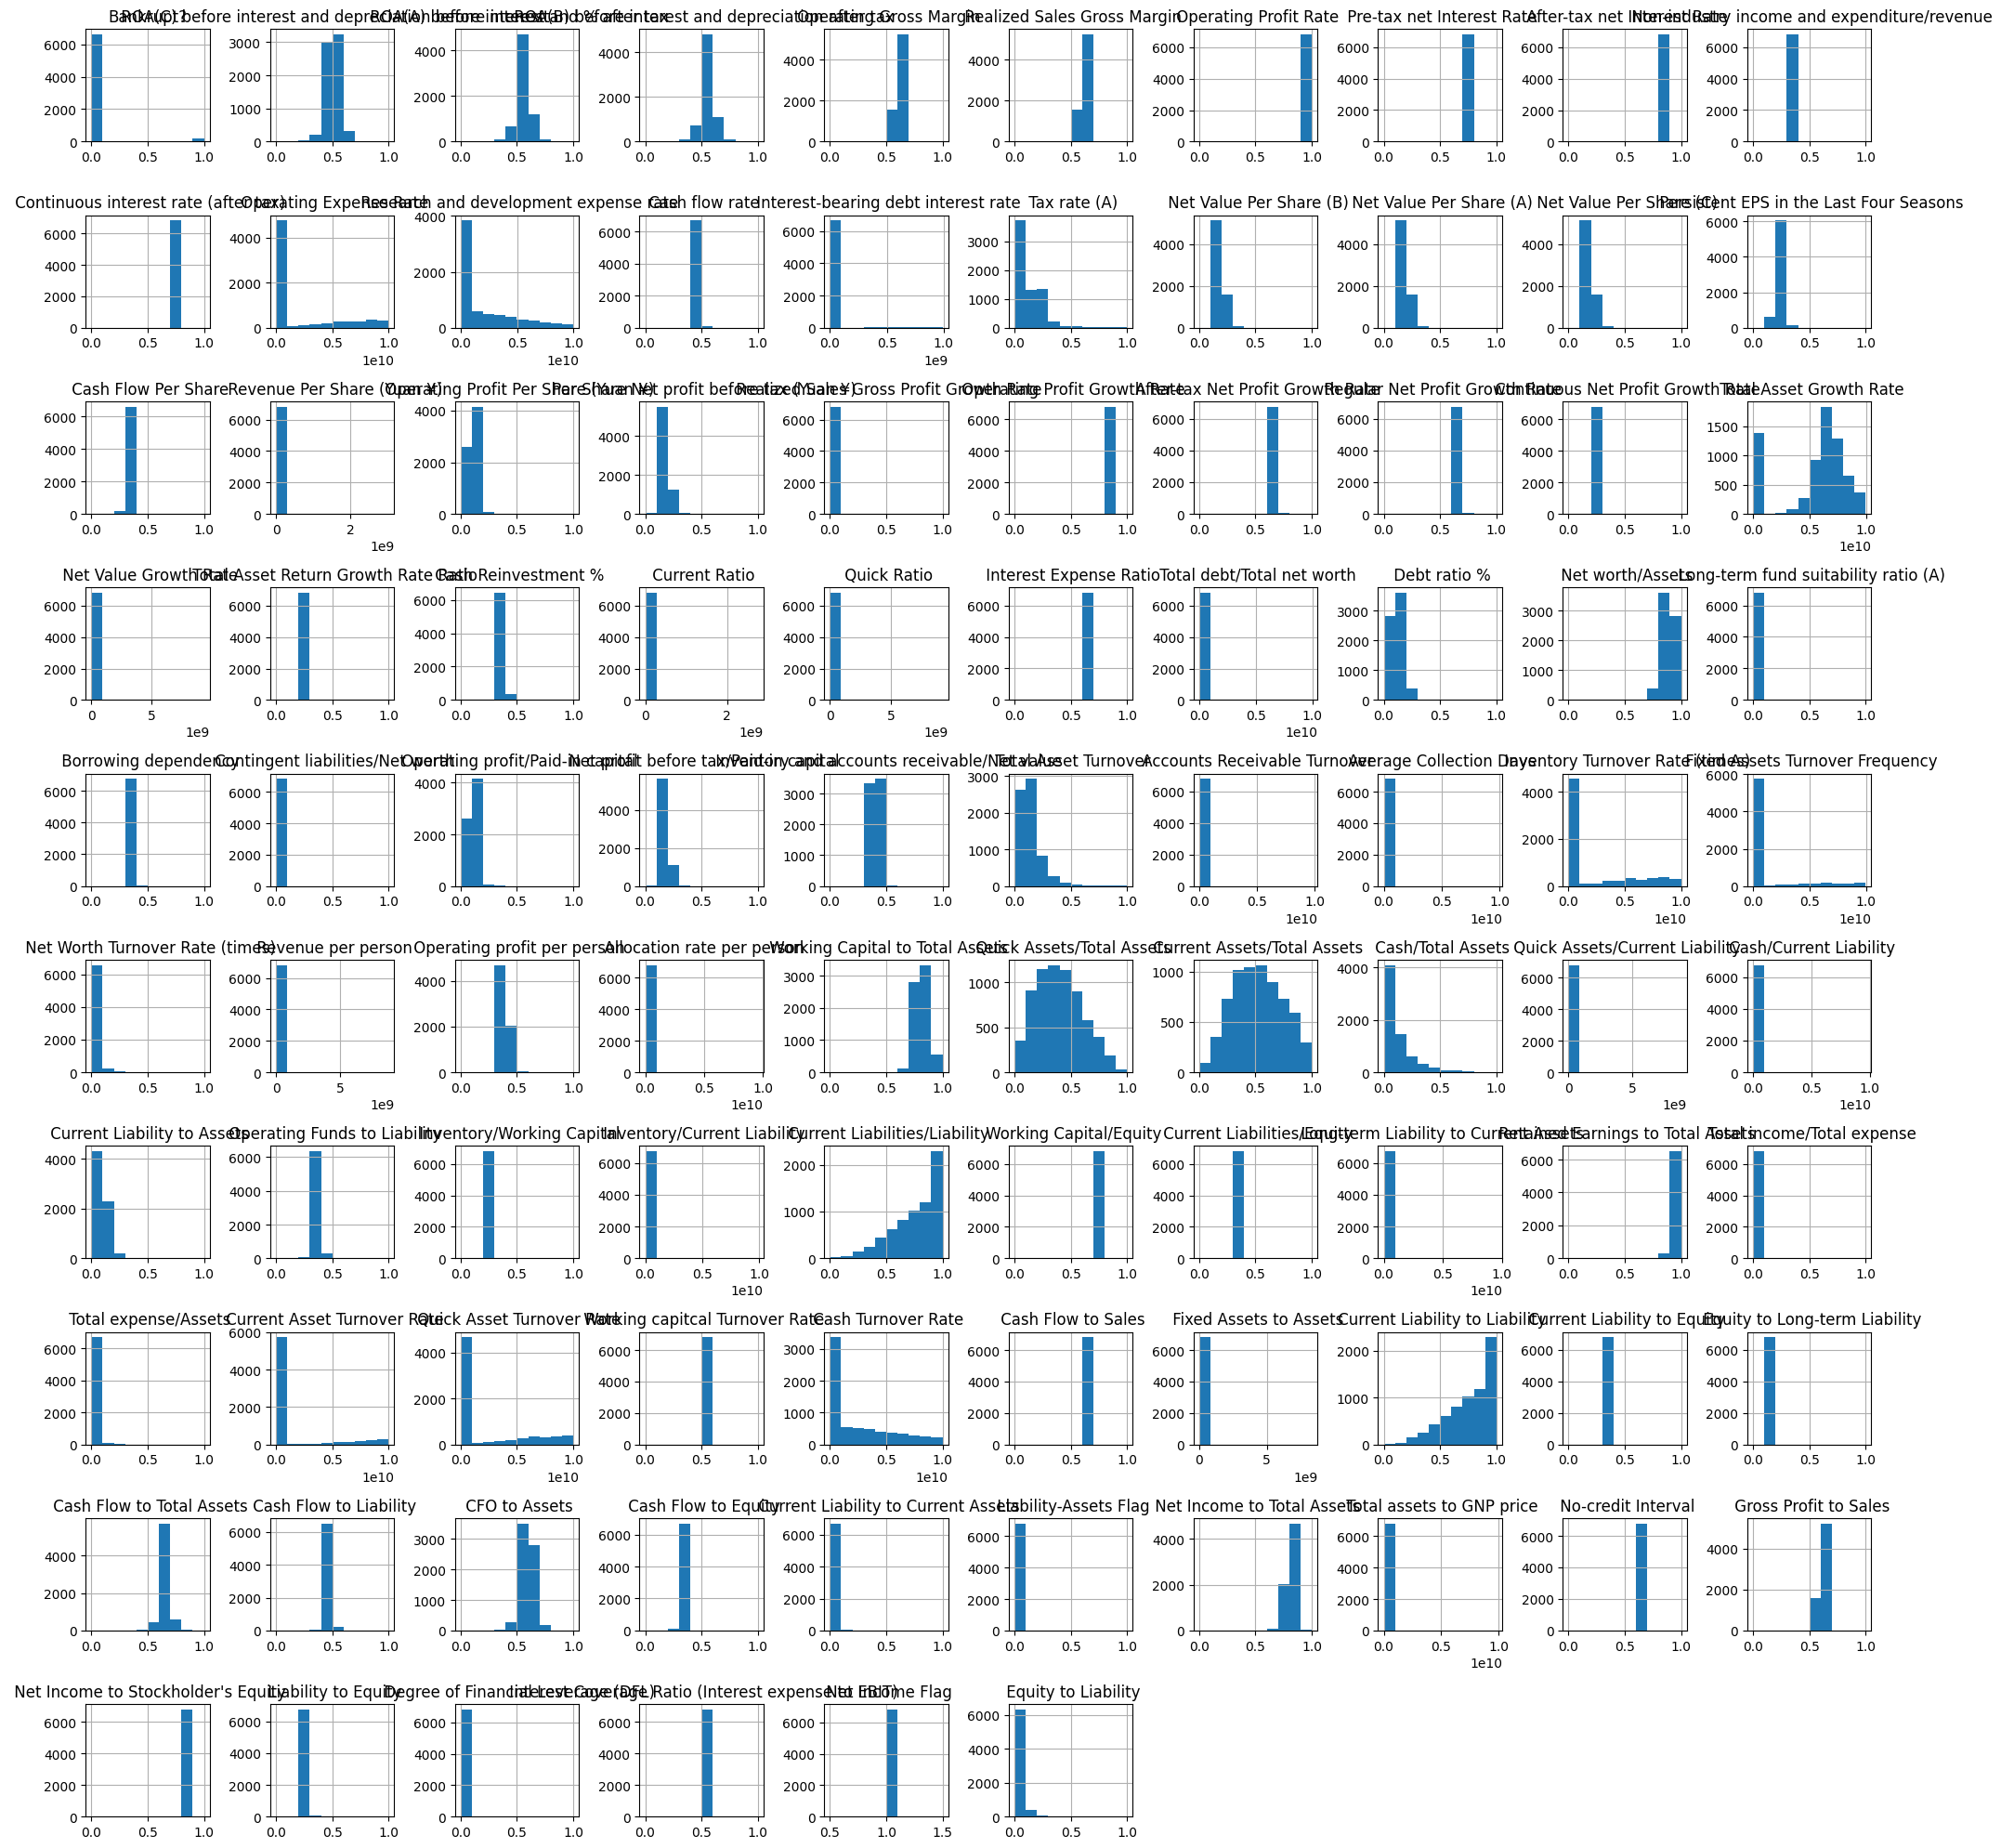

In [12]:
import numpy as np
import matplotlib.pyplot as plt

numeric_columns = df.select_dtypes(include=np.number).columns

df[numeric_columns].hist(figsize=(20,20))

plt.tight_layout()
r
plt.show()

# 9. BOXPLOTS

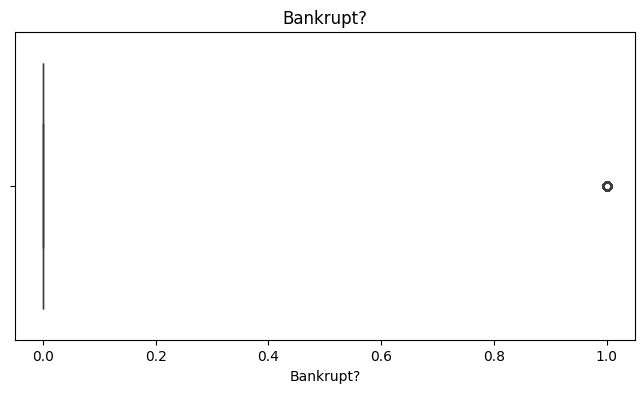

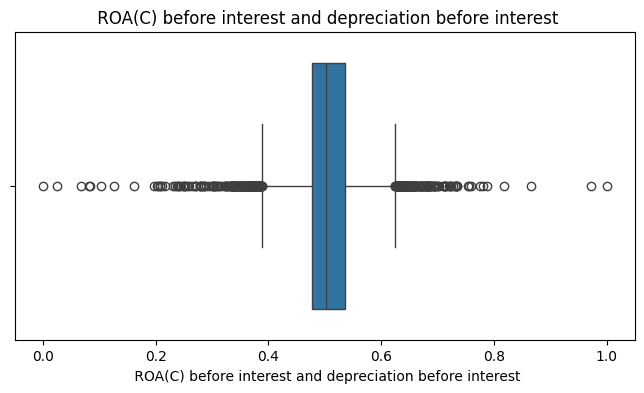

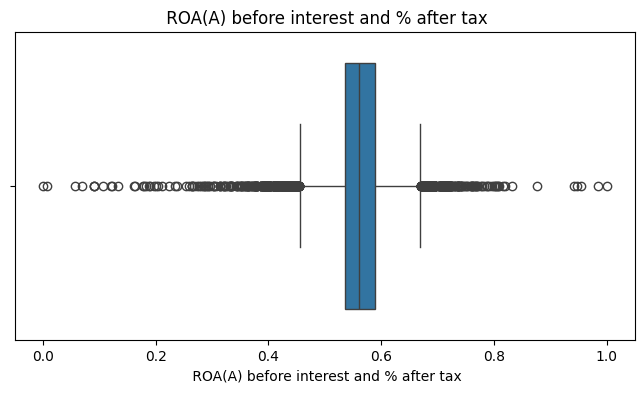

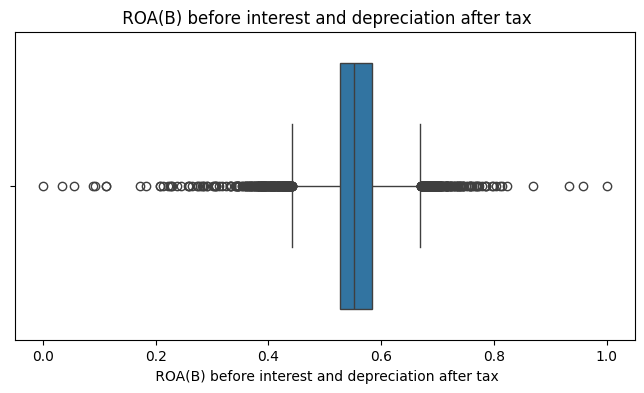

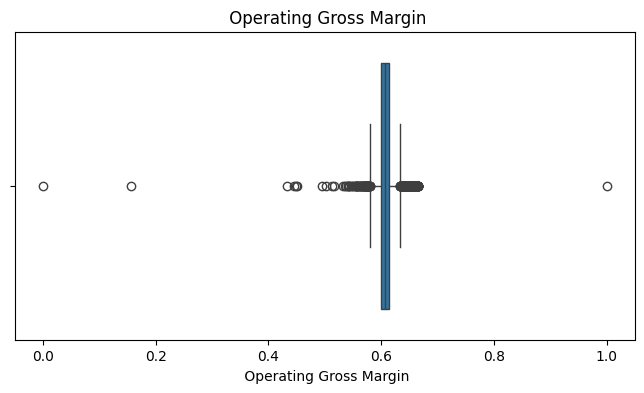

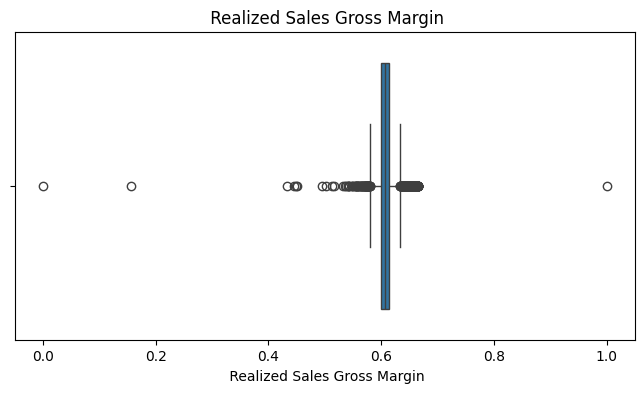

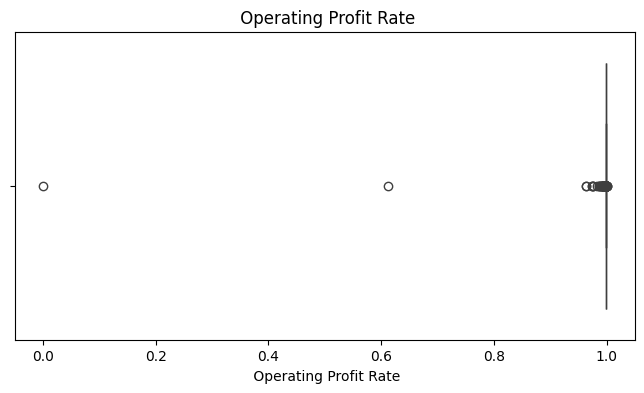

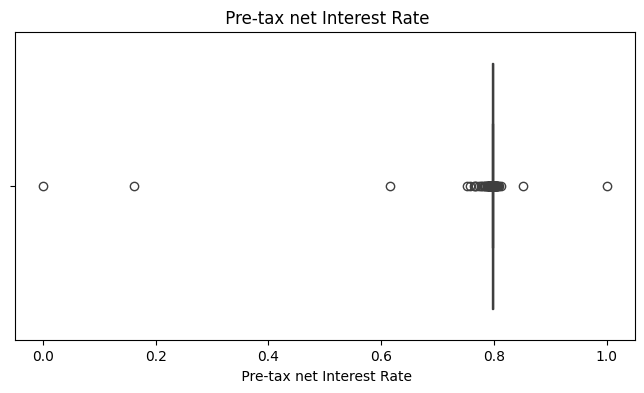

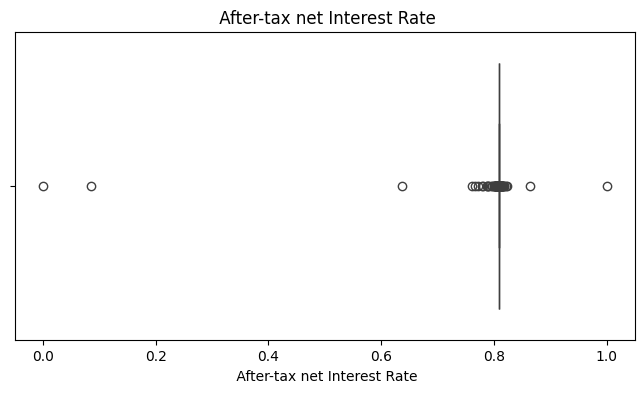

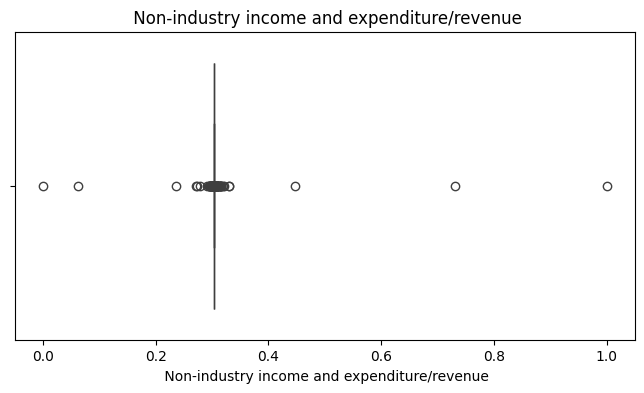

In [13]:
for col in numeric_columns[:10]:
    plt.figure(figsize=(8,4))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

# 10. CORRELATION MATRIX


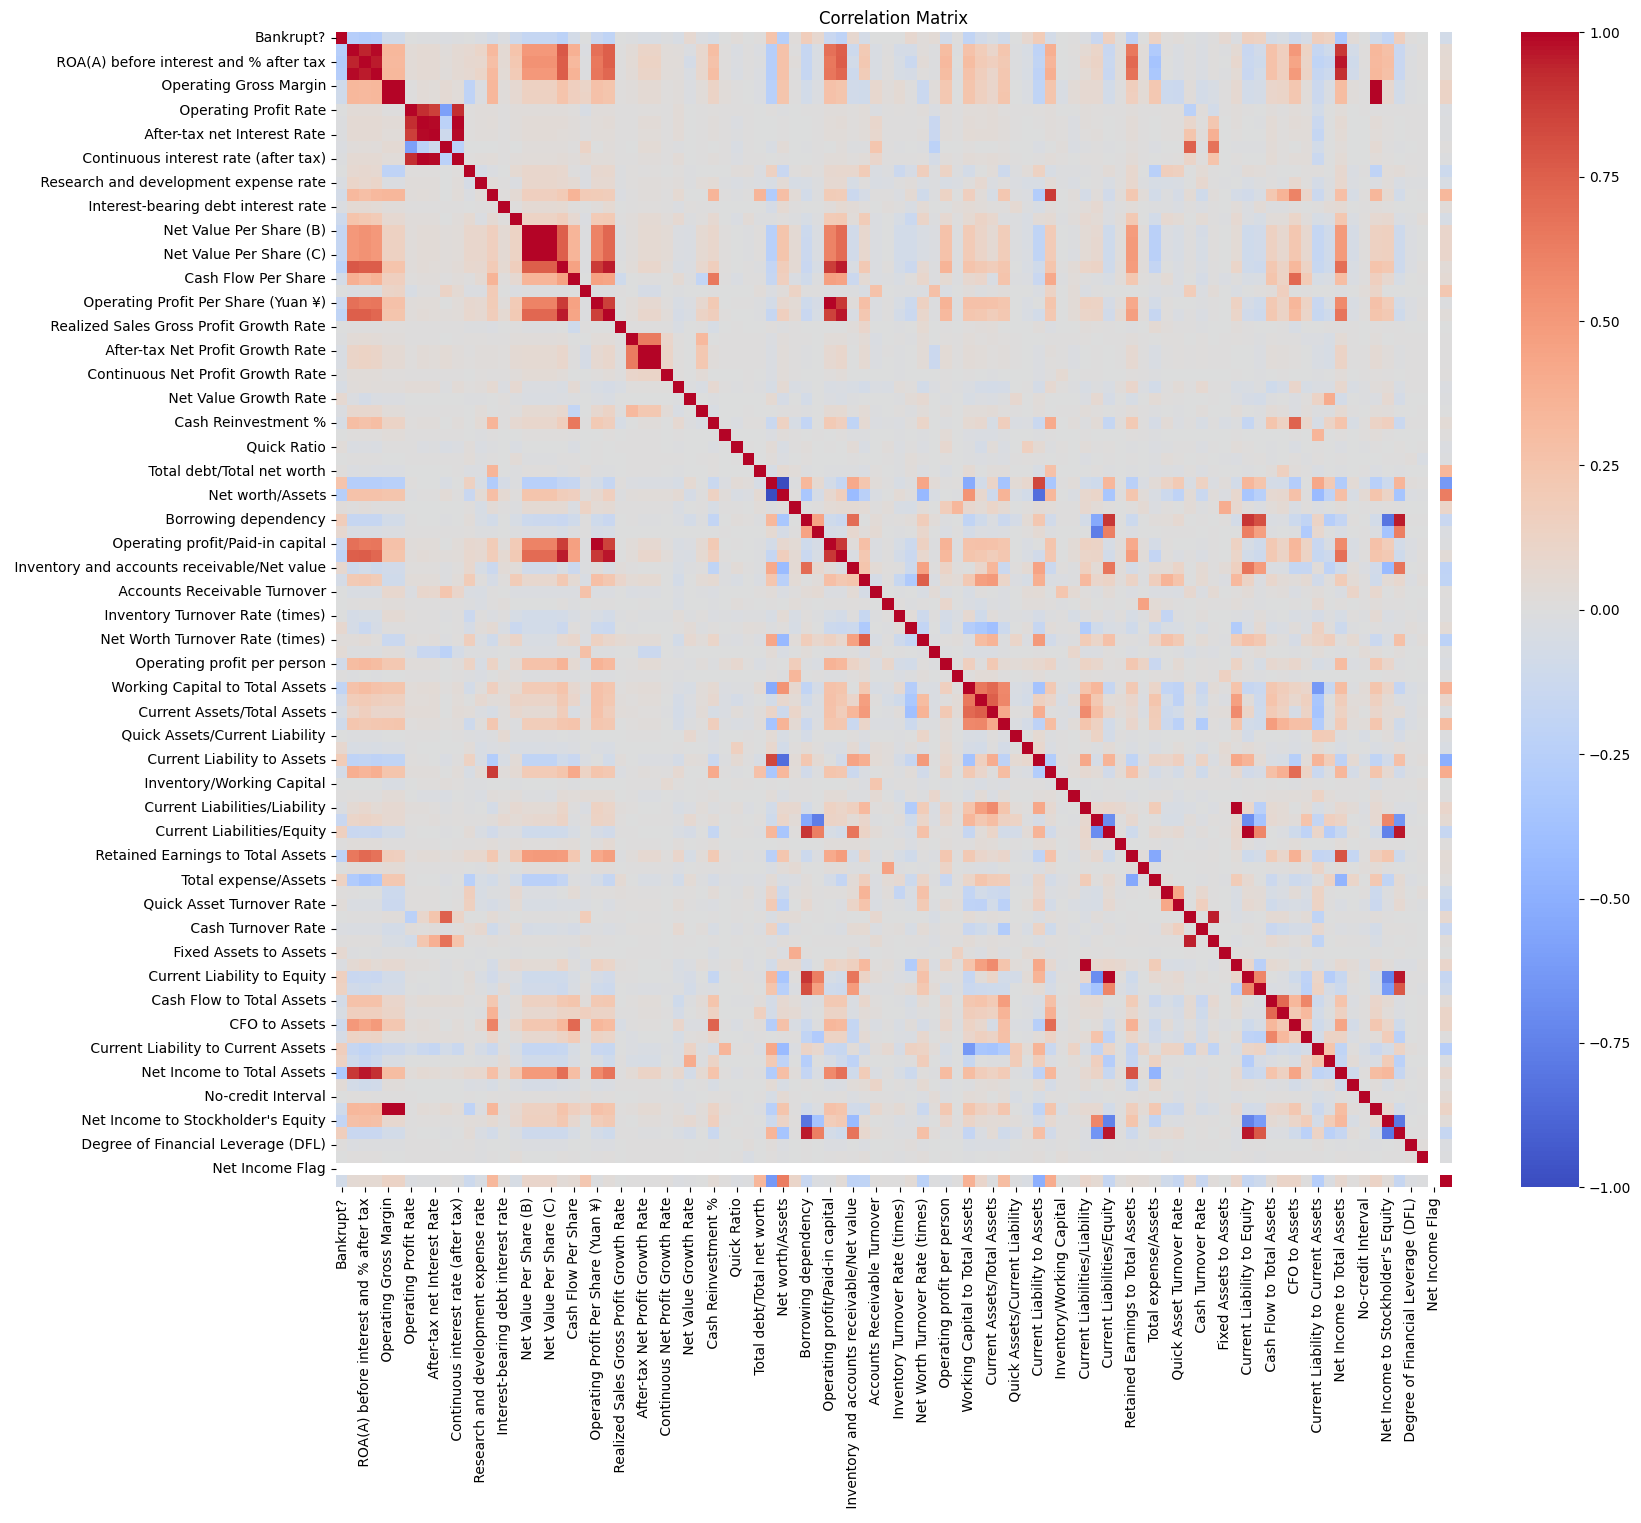

In [14]:
corr = df.corr()

plt.figure(figsize=(18,15))

sns.heatmap(corr,
            cmap="coolwarm",
            center=0)

plt.title("Correlation Matrix")

plt.show()

# 11. VARIABLES MOST CORRELATED WITH BANKRUPTCY

In [15]:
target_corr = corr["Bankrupt?"].sort_values(ascending=False)

print("="*60)
print("CORRELATION WITH BANKRUPTCY")
print("="*60)

print(target_corr)

print("\n")

print("Top Positive Correlations")

print(target_corr.head(15))

print("\n")

print("Top Negative Correlations")

print(target_corr.tail(15))

CORRELATION WITH BANKRUPTCY
Bankrupt?                                                   1.000000
 Debt ratio %                                               0.250161
 Current Liability to Assets                                0.194494
 Borrowing dependency                                       0.176543
 Current Liability to Current Assets                        0.171306
                                                              ...   
 ROA(C) before interest and depreciation before interest   -0.260807
 ROA(B) before interest and depreciation after tax         -0.273051
 ROA(A) before interest and % after tax                    -0.282941
 Net Income to Total Assets                                -0.315457
 Net Income Flag                                                 NaN
Name: Bankrupt?, Length: 96, dtype: float64


Top Positive Correlations
Bankrupt?                                       1.000000
 Debt ratio %                                   0.250161
 Current Liability to Asset

# 12. TOP 20 IMPORTANT VARIABLES

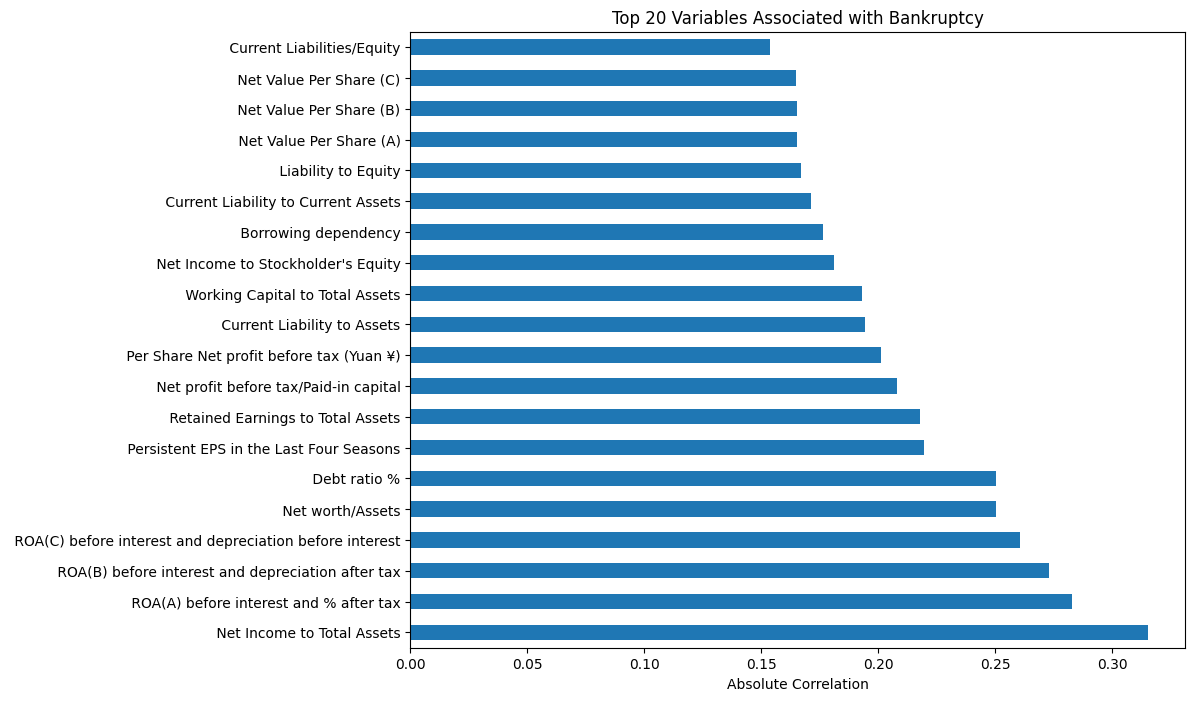

In [16]:
top = target_corr.abs().sort_values(ascending=False)[1:21]

plt.figure(figsize=(10,8))

top.plot(kind='barh')

plt.title("Top 20 Variables Associated with Bankruptcy")

plt.xlabel("Absolute Correlation")

plt.show()

# 13. OUTLIER DETECTION USING IQR

In [17]:
print("="*60)
print("OUTLIER DETECTION")
print("="*60)

for column in numeric_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    outliers = df[(df[column] < lower) | (df[column] > upper)]

    print(column, ":", len(outliers))


OUTLIER DETECTION
Bankrupt? : 220
 ROA(C) before interest and depreciation before interest : 391
 ROA(A) before interest and % after tax : 561
 ROA(B) before interest and depreciation after tax : 432
 Operating Gross Margin : 320
 Realized Sales Gross Margin : 318
 Operating Profit Rate : 716
 Pre-tax net Interest Rate : 773
 After-tax net Interest Rate : 867
 Non-industry income and expenditure/revenue : 1094
 Continuous interest rate (after tax) : 806
 Operating Expense Rate : 0
 Research and development expense rate : 182
 Cash flow rate : 576
 Interest-bearing debt interest rate : 396
 Tax rate (A) : 120
 Net Value Per Share (B) : 457
 Net Value Per Share (A) : 464
 Net Value Per Share (C) : 465
 Persistent EPS in the Last Four Seasons : 508
 Cash Flow Per Share : 532
 Revenue Per Share (Yuan ¥) : 478
 Operating Profit Per Share (Yuan ¥) : 442
 Per Share Net profit before tax (Yuan ¥) : 511
 Realized Sales Gross Profit Growth Rate : 814
 Operating Profit Growth Rate : 1008
 After-t

# 14. SKEWNESS

In [18]:
print("="*60)
print("SKEWNESS")
print("="*60)

print(df.skew())

SKEWNESS
Bankrupt?                                                    5.295388
 ROA(C) before interest and depreciation before interest    -0.323941
 ROA(A) before interest and % after tax                     -1.033727
 ROA(B) before interest and depreciation after tax          -0.763564
 Operating Gross Margin                                     -8.043368
                                                              ...    
 Liability to Equity                                        27.459467
 Degree of Financial Leverage (DFL)                         45.724197
 Interest Coverage Ratio (Interest expense to EBIT)        -13.939528
 Net Income Flag                                             0.000000
 Equity to Liability                                         7.401101
Length: 96, dtype: float64


# 15. KURTOSIS

In [19]:
print("="*60)
print("KURTOSIS")
print("="*60)

print(df.kurt())

KURTOSIS
Bankrupt?                                                     26.048769
 ROA(C) before interest and depreciation before interest       6.390770
 ROA(A) before interest and % after tax                        9.038785
 ROA(B) before interest and depreciation after tax             7.929074
 Operating Gross Margin                                      365.540671
                                                               ...     
 Liability to Equity                                        1209.203491
 Degree of Financial Leverage (DFL)                         2475.433404
 Interest Coverage Ratio (Interest expense to EBIT)          911.800905
 Net Income Flag                                               0.000000
 Equity to Liability                                          94.066170
Length: 96, dtype: float64


# 16. SAVE SUMMARY

In [20]:
summary = df.describe().T

summary.to_csv("SummaryStatistics.csv")

print("\nSummary statistics saved successfully.")


Summary statistics saved successfully.
